# Классификация текстов с использованием Наивного Байесовского Классификатора

## Задание 1 (1 балл)

Откройте данные. Узнайте, сколько в них спам- и не спам-писем. Визуализируйте полученные соотношение подходящим образом.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

spam_data = pd.read_csv('spam_or_not_spam.csv')

spam_data.head()

,email,label
0,date wed NUMBER aug NUMBER NUMBER NUMBER NUMB...,0
1,martin a posted tassos papadopoulos the greek ...,0
2,man threatens explosion in moscow thursday aug...,0
3,klez the virus that won t die already the most...,0
4,in adding cream to spaghetti carbonara which ...,0


In [14]:
label_counts = spam_data['label'].value_counts()

print(label_counts)

label
0    2500
1     500
Name: count, dtype: int64


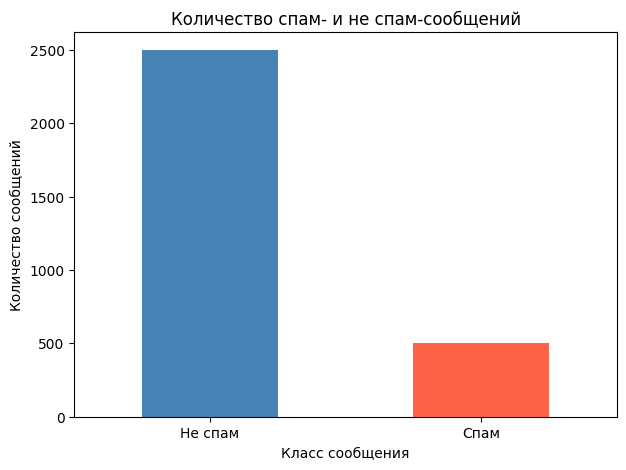

In [15]:
label_counts.plot(
    kind='bar',
    figsize=(7, 5),
    color=['steelblue', 'tomato']
)

plt.title('Количество спам- и не спам-сообщений')
plt.xlabel('Класс сообщения')
plt.ylabel('Количество сообщений')
plt.xticks(
    ticks=[0, 1],
    labels=['Не спам', 'Спам'],
    rotation=0
)

plt.show()

## Задание 2 (2 балла)

Вам необходимо предобработать ваши данные и перевести их в векторный вид. Подгрузим необходимый модуль:

In [16]:
from sklearn.feature_extraction.text import CountVectorizer

Замените в данных все пустые строки и строки, состоящие из пробелов, на пропуски (NaN). После этого удалите из данных все строки, в которых наблюдаются пропущенные значения.

In [19]:
import numpy as np

data = spam_data.copy()

data = data.replace(
    r'^\s*$',
    np.nan,
    regex=True
)

data = data.dropna()

data.shape

(2997, 2)

Переводим данные в векторный вид:

In [20]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(data["email"])

Определите, сколько теперь признаков в нашем наборе данных:

In [21]:
print(X.shape)
print('Количество признаков:', X.shape[1])

(2997, 34116)
Количество признаков: 34116


## Задание 3 (2 балла)

Определите целевую переменную и признаки:

In [22]:
y = data['label']

Разделите выборку на обучающую и тестовую, используя стратифицированное разбиение (параметр `stratify` установите в значение вектора ответов y) размер тестовой выборки (`test_size`) возьмите как 0.25, параметр `random_state` определите со значением 42:

In [ ]:
X = vectorizer.fit_transform(data['email'])

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.75,
    test_size=0.25,
    stratify=y,
    random_state=42
)

Рассчитайте среднее значение целевой переменной по тестовой выборке:

In [27]:
test_target_mean = round(y_test.mean(), 3)

print(test_target_mean)

0.165


## Задание 4 (3 балла)

Определите и обучите подходящий алгоритм с параметром alpha = 0.01

In [28]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB(alpha=0.01)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

Оцените результат с точки зрения всех известных вам метрик (не менее трёх):

In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f'Accuracy: {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1-score: {f1:.3f}')
print(f'ROC-AUC: {roc_auc:.3f}')

print('\nМатрица ошибок:')
print(confusion_matrix(y_test, y_pred))

print('\nОтчёт классификации:')
print(classification_report(y_test, y_pred))

Accuracy: 0.987
Precision: 1.000
Recall: 0.919
F1-score: 0.958
ROC-AUC: 0.995

Матрица ошибок:
[[626   0]
 [ 10 114]]

Отчёт классификации:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       626
           1       1.00      0.92      0.96       124

    accuracy                           0.99       750
   macro avg       0.99      0.96      0.98       750
weighted avg       0.99      0.99      0.99       750



Нарисуйте ROC-кривую:

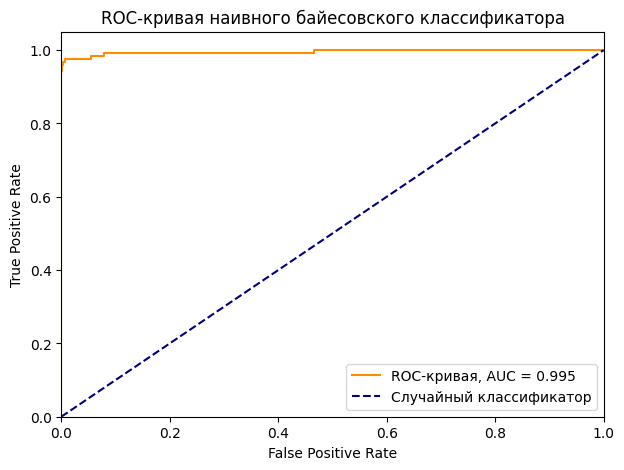

In [30]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    color='darkorange',
    label=f'ROC-кривая, AUC = {roc_auc:.3f}'
)

plt.plot(
    [0, 1],
    [0, 1],
    color='navy',
    linestyle='--',
    label='Случайный классификатор'
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая наивного байесовского классификатора')
plt.legend(loc='lower right')
plt.show()

## Задание 5 (3 балла)

Переберите несколько значений alpha с помощью кросс-валидации. Оцените, зависит ли от этого параметра качество классификации.

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.naive_bayes import MultinomialNB

alpha_values = [0.001, 0.01, 0.1, 1, 10, 100]

cross_validator = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

for alpha in alpha_values:
    model = MultinomialNB(alpha=alpha)

    accuracy_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cross_validator,
        scoring='accuracy'
    )

    f1_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cross_validator,
        scoring='f1'
    )

    results.append({
        'alpha': alpha,
        'accuracy_mean': accuracy_scores.mean(),
        'accuracy_std': accuracy_scores.std(),
        'f1_mean': f1_scores.mean(),
        'f1_std': f1_scores.std()
    })

results = pd.DataFrame(results)

print(results.round(4))

     alpha  accuracy_mean  accuracy_std  f1_mean  f1_std
0    0.001         0.9862        0.0049   0.9567  0.0162
1    0.010         0.9902        0.0044   0.9696  0.0137
2    0.100         0.9920        0.0023   0.9756  0.0070
3    1.000         0.9898        0.0023   0.9685  0.0071
4   10.000         0.8790        0.0076   0.4242  0.0575
5  100.000         0.8429        0.0047   0.1003  0.0529
